# Imports & paths

In [10]:
library(tidyverse)
library(lme4)
library(lmerTest)

In [11]:
run_timestamp <- format(Sys.time(), "%Y%m%d_%H%M%S")
plots_dir <- file.path("power_analysis", "plots", paste0("type1_", run_timestamp))
dir.create(plots_dir, recursive = TRUE, showWarnings = FALSE)
# results_path <- "power_analysis/simulation_results.csv"
results_path <- file.path("power_analysis", paste0("results_type1_", run_timestamp, ".csv"))
pilot_data_path <- file.path("../pilot2/data/processed/pilot2_edit_events.csv")

# Pilot data

## Inspect and process

In [12]:
pilot_df <- read_csv(pilot_data_path)

Rows: 88 Columns: 14


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): chain, participant, original, edited, explanation, explanation_embe...
dbl (8): generation, edit_idx, sentence_idx, pc1, pc2, pc3, pc4, pc5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
# keep only observations from chains that appear in both generations
pilot_df <- pilot_df %>%
    group_by(chain) %>%
    filter(any(generation == 1) & any(generation == 2)) %>%
    ungroup()

# inspect pilot data
pilot_df %>%
    group_by(chain, generation) %>%
    summarise(observations = n(), .groups = "drop") %>%
    print(observations = Inf)


# A tibble: 10 × 3
   chain generation observations
   <chr>      <dbl>        <int>
 1 A              1            7
 2 A              2            9
 3 B              1            8
 4 B              2            7
 5 E              1            8
 6 E              2            9
 7 I              1            2
 8 I              2            6
 9 J              1            7
10 J              2            8


In [14]:
summary(pilot_df)

       chain      generation       participant    edit_idx     sentence_idx   
 Length   :71   Min.   :1.000   Length   :71   Min.   :1.00   Min.   : 0.000  
 N.unique : 5   1st Qu.:1.000   N.unique :10   1st Qu.:2.00   1st Qu.: 2.000  
 N.blank  : 0   Median :2.000   N.blank  : 0   Median :4.00   Median : 4.000  
 Min.nchar: 1   Mean   :1.549   Min.nchar:17   Mean   :4.31   Mean   : 4.352  
 Max.nchar: 1   3rd Qu.:2.000   Max.nchar:17   3rd Qu.:6.00   3rd Qu.: 6.500  
                Max.   :2.000                  Max.   :9.00   Max.   :13.000  
      original         edited       explanation  explanation_embedding
 Length   : 71   Length   : 71   Length   : 71   Length   :   71      
 N.unique : 70   N.unique : 66   N.unique : 71   N.unique :   71      
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :    0      
 Min.nchar: 34   Min.nchar: 56   Min.nchar: 10   Min.nchar:12480      
 Max.nchar:338   Max.nchar:577   Max.nchar:716   Max.nchar:12480      
                 NAs 

## Fit models on pilot data

In [15]:
# baseline center generation (generation 1 = 0)
pilot_df <- pilot_df %>%
    mutate(
        generation_num = as.numeric(generation),
        generation_centered = generation_num - 1
    )

### Check if considered models indeed behave similarly on this data

In [16]:
m1 <- lmer(
    pc2 ~ generation_centered + (1 | chain/participant),
    data = pilot_df
)
summary(m1)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 429.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08388 -0.61194 -0.05697  0.62286  2.31241 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept)  0.7099  0.8426  
 chain             (Intercept) 20.6364  4.5427  
 Residual                      22.6291  4.7570  
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)           -1.202      2.247  4.924  -0.535    0.616
generation_centered    1.319      1.273  3.977   1.036    0.359

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.316

In [17]:
m2 <- lmer(
    pc2 ~ generation_centered + (1 | chain) + (1 | participant),
    data = pilot_df
)
summary(m2)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain) + (1 | participant)
   Data: pilot_df

REML criterion at convergence: 429.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08388 -0.61194 -0.05697  0.62286  2.31241 

Random effects:
 Groups      Name        Variance Std.Dev.
 participant (Intercept)  0.7099  0.8426  
 chain       (Intercept) 20.6364  4.5427  
 Residual                22.6291  4.7570  
Number of obs: 71, groups:  participant, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)           -1.202      2.247  4.924  -0.535    0.616
generation_centered    1.319      1.273  3.977   1.036    0.359

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.316

In [18]:
m3 <- lmer(
    pc2 ~ generation_centered + (1 | chain/generation),
    data = pilot_df
)
summary(m3)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain/generation)
   Data: pilot_df

REML criterion at convergence: 429.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08388 -0.61194 -0.05697  0.62286  2.31241 

Random effects:
 Groups           Name        Variance Std.Dev.
 generation:chain (Intercept)  0.7099  0.8426  
 chain            (Intercept) 20.6364  4.5427  
 Residual                     22.6291  4.7570  
Number of obs: 71, groups:  generation:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)           -1.202      2.247  4.924  -0.535    0.616
generation_centered    1.319      1.273  3.977   1.036    0.359

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.316

In [19]:
AIC(m1, m2, m3)
BIC(m1, m2, m3)

,df,AIC
,<dbl>,<dbl>
m1,5,439.3717
m2,5,439.3717
m3,5,439.3717


,df,BIC
,<dbl>,<dbl>
m1,5,450.6851
m2,5,450.6851
m3,5,450.6851


In [20]:
# check correlations of predictions from different models

preds <- data.frame(
    m1 = predict(m1),
    m2 = predict(m2),
    m3 = predict(m3)
)

cor(preds)

,m1,m2,m3
m1,1,1,1
m2,1,1,1
m3,1,1,1


In [21]:
# check distances between predictions of different models

n_models <- ncol(preds)
dist_mat <- matrix(NA, n_models, n_models)

models <- names(preds)

for(i in 1:n_models){
    for(j in 1:n_models){
        dist_mat[i, j] <- mean((preds[[i]] - preds[[j]])^2)
    }
}

rownames(dist_mat) <- models
colnames(dist_mat) <- models

dist_mat

,m1,m2,m3
m1,0.000000e+00,0.000000e+00,5.970225e-22
m2,0.000000e+00,0.000000e+00,5.970225e-22
m3,5.970225e-22,5.970225e-22,0.000000e+00


All three models produce effectively identical fitted values, with pairwise mean squared prediction differences near machine precision ($<10^{−8}$). Thus, the models are empirically indistinguishable with respect to in-sample prediction.

In [22]:
m4 <- lmer(
    pc2 ~ generation_centered + 
    (1 | chain) + # random intercept for chain, 
    (0 + generation | chain) + # random slope for generation by chain
    (1 | chain : participant), # random intercept for participant nested within chain
    data = pilot_df
)
summary(m4)

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain) + (0 + generation | chain) +  
    (1 | chain:participant)
   Data: pilot_df

REML criterion at convergence: 429.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08388 -0.61193 -0.05698  0.62286  2.31240 

Random effects:
 Groups            Name        Variance  Std.Dev. 
 chain.participant (Intercept) 7.101e-01 0.8426447
 chain             generation  1.628e-08 0.0001276
 chain.1           (Intercept) 2.064e+01 4.5426573
 Residual                      2.263e+01 4.7570086
Number of obs: 71, groups:  chain:participant, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)           -1.202      2.247  4.924  -0.535    0.616
generation_centered    1.319      1.273  3.977   1.036    0.359

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.316
optimizer (nloptwrap) converg

### Fit model for different PCs

In [23]:
m_pc1_pilot <- lmer(
    pc1 ~ generation_centered + (1 | chain/participant),
    data = pilot_df
)
summary(m_pc1_pilot)

# NOTE: model for pc1 is singular

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc1 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 425.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.6151 -0.6719 -0.0034  0.5274  3.7444 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept) 12.95    3.599   
 chain             (Intercept)  0.00    0.000   
 Residual                      20.89    4.570   
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error      df t value Pr(>|t|)
(Intercept)          -1.2021     1.8358  7.9143  -0.655    0.531
generation_centered  -0.3214     2.5509  7.5133  -0.126    0.903

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.720
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


In [24]:
m_pc2_pilot <- lmer(
    pc2 ~ generation_centered + (1 | chain/participant),
    data = pilot_df
)
summary(m_pc2_pilot)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 429.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08388 -0.61194 -0.05697  0.62286  2.31241 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept)  0.7099  0.8426  
 chain             (Intercept) 20.6364  4.5427  
 Residual                      22.6291  4.7570  
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)           -1.202      2.247  4.924  -0.535    0.616
generation_centered    1.319      1.273  3.977   1.036    0.359

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.316

In [25]:
m_pc3_pilot <- lmer(
    pc3 ~ generation_centered + (1 | chain / participant),
    data = pilot_df
)
summary(m_pc3_pilot)

# NOTE: model for pc3 is singular

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc3 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 447.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.20062 -0.70212 -0.06494  0.64319  2.48386 

Random effects:
 Groups            Name        Variance  Std.Dev. 
 participant:chain (Intercept) 1.084e+00 1.0409992
 chain             (Intercept) 1.224e-07 0.0003498
 Residual                      3.393e+01 5.8250991
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)  
(Intercept)            1.755      1.141  8.376   1.538   0.1609  
generation_centered   -3.484      1.547  7.694  -2.253   0.0556 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.738
optimizer (nloptwrap) convergence code: 0 (OK)
boundar

In [26]:
m_pc4_pilot <- lmer(
    pc4 ~ generation_centered + (1 | chain / participant),
    data = pilot_df
)
summary(m_pc4_pilot)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc4 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 433.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.1988 -0.5486  0.1883  0.6960  1.7763 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept)  2.755   1.660   
 chain             (Intercept)  3.212   1.792   
 Residual                      25.335   5.033   
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error     df t value Pr(>|t|)
(Intercept)            1.158      1.438  7.697   0.805    0.445
generation_centered   -2.806      1.619  4.451  -1.733    0.151

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.609

In [27]:
m_pc5_pilot <- lmer(
    pc5 ~ generation_centered + (1 | chain / participant),
    data = pilot_df
)
summary(m_pc5_pilot)

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc5 ~ generation_centered + (1 | chain/participant)
   Data: pilot_df

REML criterion at convergence: 424

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.6699 -0.7435 -0.0744  0.8397  2.6556 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept)  8.122   2.850   
 chain             (Intercept)  0.000   0.000   
 Residual                      21.258   4.611   
Number of obs: 71, groups:  participant:chain, 10; chain, 5

Fixed effects:
                    Estimate Std. Error      df t value Pr(>|t|)
(Intercept)          -0.5500     1.5465  8.3215  -0.356    0.731
generation_centered  -0.3681     2.1380  7.8362  -0.172    0.868

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.723
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


# One simulation (PC2)

## Parameters

In [35]:
# SAMPLE SIZE
max_sample_size <- 106 # for 500 euros
n_chains <- 21 
n_gens <- floor(max_sample_size / n_chains)
n_participants <- n_chains * n_gens
cat("Planned number of participants:", n_participants, "\n")
cat("Planned number of chains:      ", n_chains, "\n")
cat("Planned number of generations: ", n_gens, "\n")

Planned number of participants: 105 
Planned number of chains:       21 
Planned number of generations:  5 


Average observations per participant in pilot data: 7.1 
Range: 2 - 9 


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


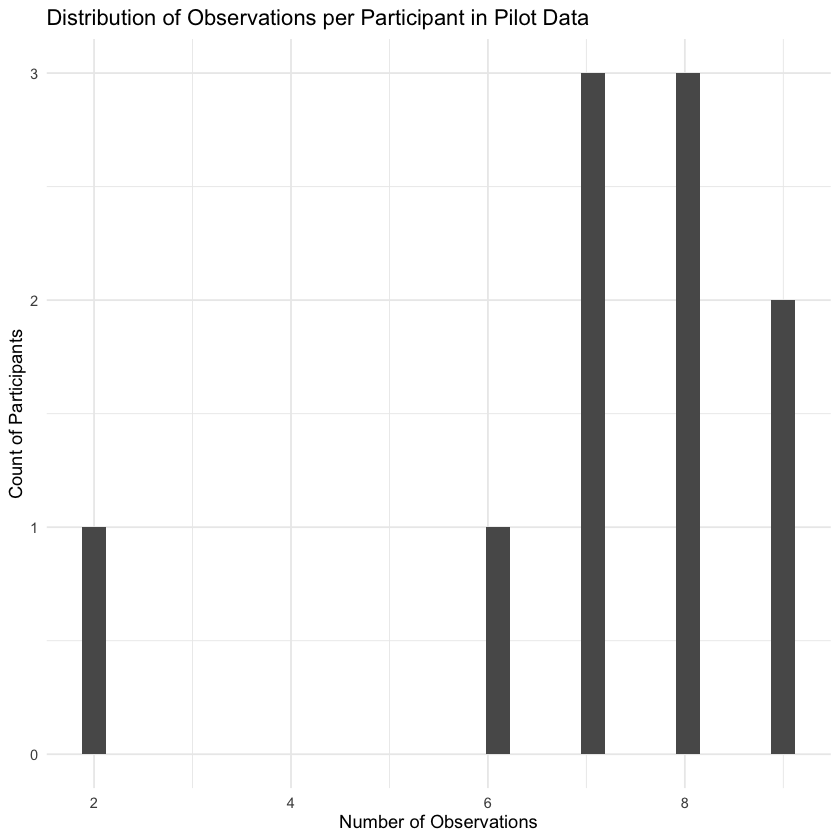

In [ ]:
# num observations per participant, based on pilot data
obs_per_participant <- pilot_df %>%
    group_by(participant) %>%
    summarise(observations = n(), .groups = "drop") %>%
    pull(observations)
avg_obs_per_participant <- mean(obs_per_participant)

cat("Average observations per participant in pilot data:", avg_obs_per_participant, "\n")
cat("Range:", min(obs_per_participant), "-", max(obs_per_participant), "\n")

# plot histogram of observations per participant
obs_plot <- ggplot(pilot_df %>%
    group_by(participant) %>%
    summarise(observations = n(), .groups = "drop")) +
    geom_histogram(aes(x = observations)) +
    labs(title = "Distribution of Observations per Participant in Pilot Data",
         x = "Number of Observations",
         y = "Count of Participants") +
    theme_classic()
print(obs_plot)

In [37]:
# VARIANCE COMPONENTS based on pilot model

pilot_model <- m_pc2_pilot

# between-chain intercept SD
sigma_chain_fitted <- attr(VarCorr(pilot_model)$chain, "stddev")["(Intercept)"]
cat("Between-chain intercept SD (fitted):  ", sigma_chain_fitted, "\n")

# between-participant SD
    # (within-chain / generation-within-chain variance)
    # (variability in participant means; differences across chain trajectories)
sigma_part_fitted <- attr(VarCorr(pilot_model)$`participant`, "stddev")
cat("Between-participant SD (fitted):      ", sigma_part_fitted, "\n")

# residual SD
    # (within-participant / repeated observations)
sigma_res_fitted <- sigma(pilot_model)
cat("Residual SD (fitted):                 ", sigma_res_fitted, "\n")

Between-chain intercept SD (fitted):   4.54273 
Between-participant SD (fitted):       0.842579 
Residual SD (fitted):                  4.757009 


In [38]:
# EFFECT SIZE
beta_fitted <- summary(pilot_model)$coefficients["generation_centered", "Estimate"]
cat("Generation effect (fitted):", beta_fitted, "\n")

Generation effect (fitted): 1.319242 


## Data generation with exact pilot estimates

In [39]:
# function to generate synthetic data with hypothesized effects and variance components

generate_data <- function(n_chains, n_gens, obs_per_participant, beta, sigma_chain, sigma_part, sigma_res) {
    n_participants <- n_chains * n_gens
    generation_center <- 1 # baseline center generation (generation 1 = 0)

    tib <- expand.grid(
        chain = factor(1:n_chains),
        generation = factor(1:n_gens)
    ) %>%
        mutate(
            participant = factor(row_number()),
            part_effect = rnorm(n_participants, 0, sigma_part), 
            n_obs = sample(obs_per_participant, n_participants, replace = TRUE)
        ) %>%
        mutate(chain_effect = rnorm(n_chains, 0, sigma_chain)[as.numeric(chain)]) %>%
        slice(rep(1:n(), times = n_obs)) %>%
        select(-n_obs) %>%
        group_by(participant) %>% 
        mutate(obs_id = 1:n()) %>%
        ungroup() %>%
        mutate(
            generation_centered = as.numeric(generation) - generation_center,
            pc2 = beta * generation_centered + 
                  chain_effect + part_effect + 
                  rnorm(n(), 0, sigma_res)
        ) %>%
        select(chain, generation, generation_centered, participant, obs_id, pc2)
    
    return(tib)
}

dat <- generate_data(
    n_chains = n_chains,
    n_gens = n_gens,
    obs_per_participant = obs_per_participant,
    beta = beta_fitted,
    sigma_chain = sigma_chain_fitted,
    sigma_part = sigma_part_fitted,
    sigma_res = sigma_res_fitted
)

str(dat)
head(dat, 10)

tibble [783 × 6] (S3: tbl_df/tbl/data.frame)
 $ chain              : Factor w/ 21 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 2 2 ...
 $ generation         : Factor w/ 5 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ generation_centered: num [1:783] 0 0 0 0 0 0 0 0 0 0 ...
 $ participant        : Factor w/ 105 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 2 2 ...
 $ obs_id             : int [1:783] 1 2 3 4 5 6 7 8 1 2 ...
 $ pc2                : num [1:783] -2.62 -0.459 -13.33 -4.018 -4.591 ...


chain,generation,generation_centered,participant,obs_id,pc2
<fct>,<fct>,<dbl>,<fct>,<int>,<dbl>
1,1,0,1,1,-2.6196558
1,1,0,1,2,-0.4594431
1,1,0,1,3,-13.3299141
1,1,0,1,4,-4.0184956
1,1,0,1,5,-4.5908787
1,1,0,1,6,2.1956062
1,1,0,1,7,-2.6213586
1,1,0,1,8,-2.5839892
2,1,0,2,1,4.7272631


## Model simulation

In [40]:
model <- lmer(
    pc2 ~ generation_centered + (1 | chain) + (1 | participant),
    data = dat
)
summary(model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pc2 ~ generation_centered + (1 | chain) + (1 | participant)
   Data: dat

REML criterion at convergence: 4765.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6381 -0.6922  0.0316  0.6391  3.0922 

Random effects:
 Groups      Name        Variance Std.Dev.
 participant (Intercept)  0.514   0.717   
 chain       (Intercept) 19.157   4.377   
 Residual                23.135   4.810   
Number of obs: 783, groups:  participant, 105; chain, 21

Fixed effects:
                    Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)          -1.7868     1.0071 22.8657  -1.774   0.0894 .  
generation_centered   1.4288     0.1319 82.5458  10.832   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.257

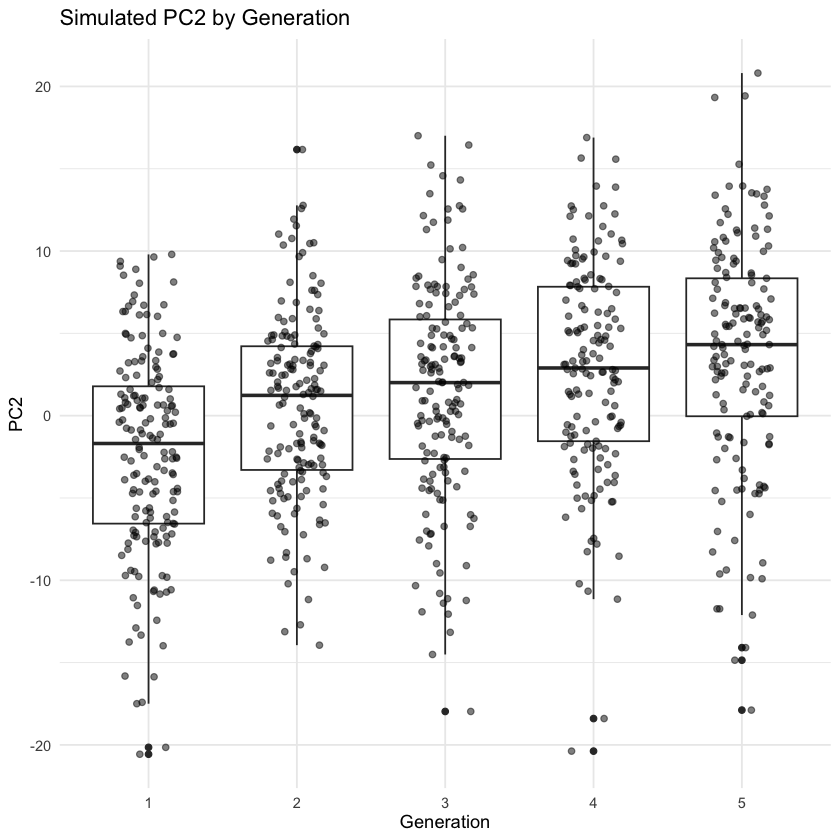

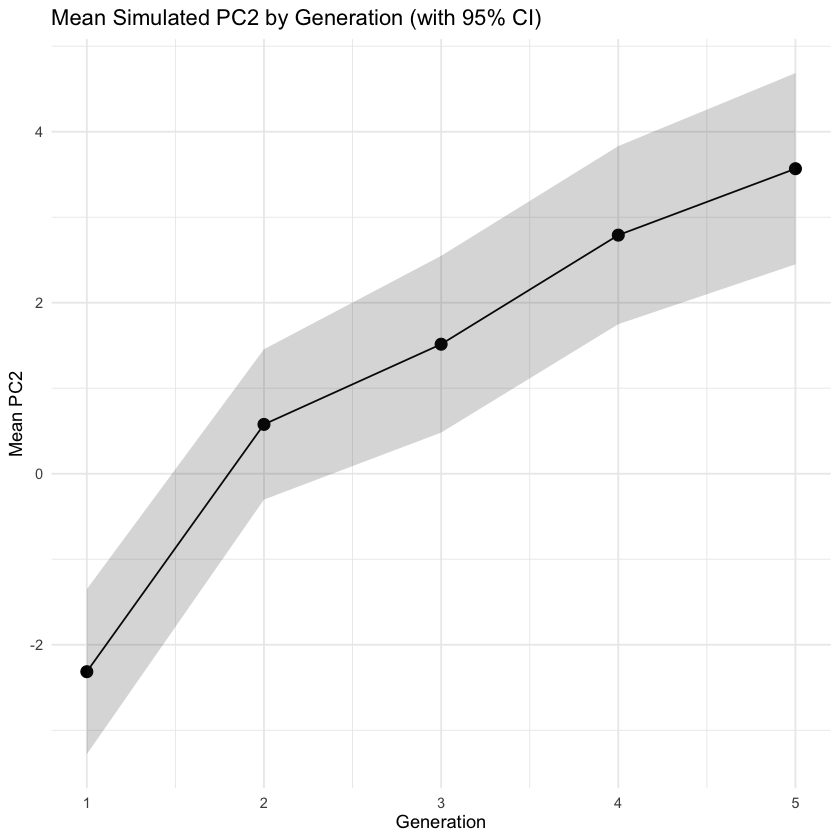

In [ ]:
# plot pc2 by generation
pc2_plot <- ggplot(dat, aes(x = generation, y = pc2))
pc2_plot <- pc2_plot + geom_boxplot() + geom_jitter(width = 0.2, alpha = 0.5)
pc2_plot <- pc2_plot + labs(title = "Simulated PC2 by Generation",
         x = "Generation",
         y = "PC2") +
    theme_classic()
print(pc2_plot)


# line plot with mean and CI
pc2_summary <- dat %>%
    group_by(generation) %>%
    summarise(
        mean_pc2 = mean(pc2),
        se_pc2 = sd(pc2) / sqrt(n()),
        ci_lower = mean_pc2 - 1.96 * se_pc2,
        ci_upper = mean_pc2 + 1.96 * se_pc2,
        .groups = "drop"
    )

pc2_line_plot <- ggplot(pc2_summary, aes(x = as.numeric(generation), y = mean_pc2)) +
    geom_line() +
    geom_point(size = 3) +
    geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper), alpha = 0.2) +
    labs(title = "Mean Simulated PC2 by Generation (with 95% CI)",
         x = "Generation",
         y = "Mean PC2") +
    theme_classic()
print(pc2_line_plot)

\subsection{Sample size}
We aimed to collect 105 responses, distributed across chains of up to five generations, which corresponds to 21 full chains, or 21 plus an additional chain for every five chains that terminate early, as described in \autoref{sec:study_design}. As will be reported in more detail in \autoref{sec:results_sustainability}, no chain terminated early, and we therefore obtained data from 21 chains spanning five generations.

Given the unavailability of previous literature on the phenomenon under investigation, the target sample size and its distribution into chains and generations was informed by previous work on Iterated Learning. Classic studies typically include 10 generations per chain \parencite{Kirby2008CumulativeCulturala,Beckner2017EmergenceLinguistic,Cornish2017SequenceMemory}, with a more variable number of chains, but commonly around 10. For example, four chains were used in \textcite{Kirby2008CumulativeCulturala}, later reanalysed using 12 chains per condition by \textcite{Beckner2017EmergenceLinguistic}, and eight chains were used in \textcite{Cornish2017SequenceMemory}.

In the present study, the distribution of the sample was shifted in favour of chain multiplicity over generation depth. This reflected the open-ended nature of the task, which allowed substantial variation in participant behaviour and therefore benefited from a larger number of independent chains to better estimate between-chain variation and support trajectory-level inference. Moreover, it was unclear whether chains would continue beyond the first generation; five generations was therefore treated as sufficiently informative evidence of iterative adaptation. Shorter chains of four to five generations are also not unprecedented in the Iterated Learning literature \parencite[e.g.,][]{Thompson2025IconicHand,Partington2025NormsEmerge}.

\subsection{Simulation-based power analysis}
To supplement the above rationale, we conducted a simulation-based power analysis for the planned analysis of explanations in \autoref{sec:analysis_explanations}. The simulations were parameterised from the pilot PC2 model and evaluated the planned 21-chain, five-generation design.

In [42]:
coef(summary(model))

,Estimate,Std. Error,df,t value,Pr(>|t|)
(Intercept),-1.786817,1.0071236,22.86568,-1.774179,8.935195e-02
generation_centered,1.428751,0.1318992,82.54584,10.832147,1.593795e-17


In [43]:
# pull out coef and p-value of generation effect 

coef <- coef(summary(model))["generation_centered", "Estimate"]
sig_gen <- coef(summary(model))["generation_centered", "Pr(>|t|)"] <= 0.05
cat("Generation effect estimate:   ", coef, "\n")
cat("Generation effect significant:", sig_gen, "\n")

Generation effect estimate:    1.428751 
Generation effect significant: TRUE 


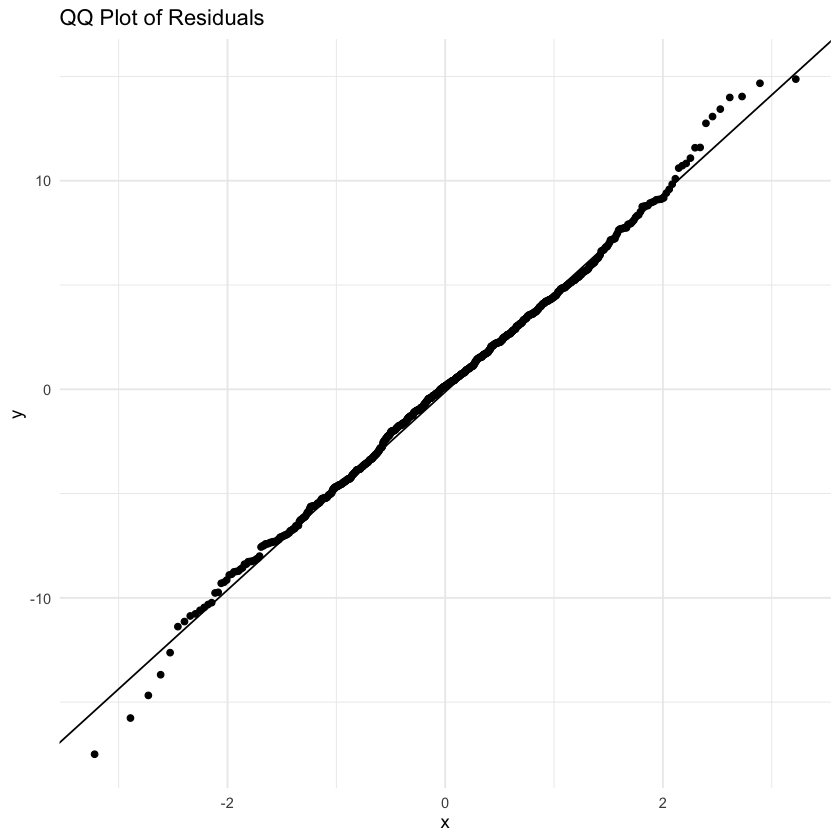

In [ ]:
# QQ plot of residuals
qq_plot <- ggplot(dat, aes(sample = resid(model))) +
    stat_qq() +
    stat_qq_line() +
    labs(title = "QQ Plot of Residuals") +
    theme_classic()
print(qq_plot)

## GAM

In [49]:
# library(mgcv)

dat$chain <- factor(dat$chain)
dat$participant <- factor(dat$participant)
dat$chain_participant <- interaction(dat$chain, dat$participant)
dat$generation <- as.numeric(as.character(dat$generation))

m <- gam(
    pc2 ~ s(generation, k = 4) +
    s(chain, bs = "re") +
    s(chain_participant, bs = "re"),
    data = dat,
    method = "REML"
)
summary(m)


Family: gaussian 
Link function: identity 

Formula:
pc2 ~ s(generation, k = 4) + s(chain, bs = "re") + s(chain_participant, 
    bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    1.015      0.972   1.044    0.297

Approximate significance of smooth terms:
                        edf  Ref.df      F p-value    
s(generation)         1.835   2.164 56.880  <2e-16 ***
s(chain)             19.278  20.000 34.180  <2e-16 ***
s(chain_participant)  9.746 103.000  0.114   0.186    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.492   Deviance explained = 51.2%
-REML = 2381.9  Scale est. = 23.129    n = 783

# Repeat simulation

In [29]:
coef_results <- c()
sig_results <- c()
singular_results <- c()

n_sim <- 1000

for (i in 1:n_sim){
    dat <- generate_data(
        n_chains = n_chains,
        n_gens = n_gens,
        obs_per_participant = obs_per_participant,
        beta = beta_fitted,
        sigma_chain = sigma_chain_fitted,
        sigma_part = sigma_part_fitted,
        sigma_res = sigma_res_fitted
    )
    
    model <- suppressMessages(suppressWarnings(lmer(
        pc2 ~ generation_centered + (1 | chain) + (1 | participant),
        data = dat
    )))
    
    coef <- coef(summary(model))["generation_centered", "Estimate"]
    coef_results[i] <- coef

    sig_gen <- coef(summary(model))["generation_centered", "Pr(>|t|)"] <= 0.05
    sig_results[i] <- sig_gen

    # store number of singular fits
    singular <- isSingular(model)
    singular_results[i] <- singular
}

power_estimate <- mean(sig_results)
cat("Estimated power for detecting generation effect:", power_estimate, "\n")

singular_rate <- mean(singular_results)
cat("Proportion of singular fits:", singular_rate, "\n")

power_usable <- mean(sig_results[!singular_results])
cat("Estimated power excluding singular fits:", power_usable, "\n")

Estimated power for detecting generation effect: 1 
Proportion of singular fits: 0.109 
Estimated power excluding singular fits: 1 


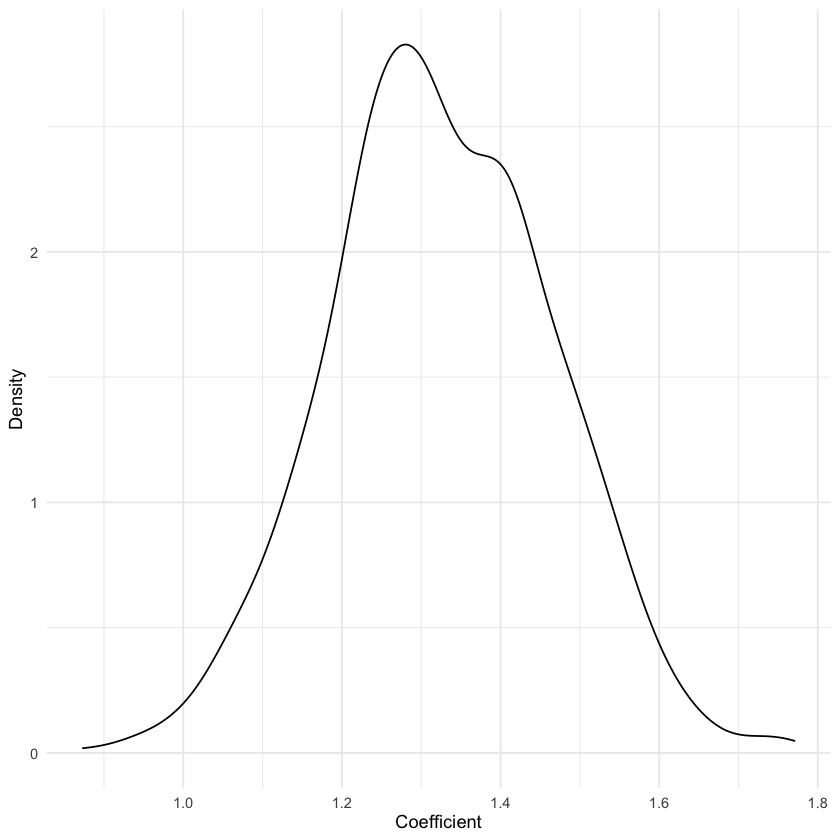

In [ ]:
results_tibble <- tibble(coef = coef_results,
                         sig = sig_results)
ggplot(results_tibble, aes(x = coef)) + 
    geom_density() + 
    theme_classic() + 
    labs(x = 'Coefficient', y = 'Density')

# Minimum detectable effect 

In [33]:
power_function <- function(n_sim = 1000,
                            beta = beta_fitted,
                            chains = n_chains,
                            gens = n_gens,
                            obs_counts = obs_per_participant,
                            sigma_chain = sigma_chain_fitted,
                            sigma_part = sigma_part_fitted,
                            sigma_res = sigma_res_fitted,
                            verbose = FALSE) {

    participants <- chains * gens
    
    # log params
    if (verbose) {
        cat("Running power simulation with parameters:\n")
        cat("beta:", beta, "| sigma_chain:", sigma_chain, "| sigma_part:", sigma_part, "| sigma_res:", sigma_res, "\n")
        flush.console()
    }

    coef_results <- numeric(n_sim)
    sig_results <- logical(n_sim)
    singular_results <- logical(n_sim)
    sig_non_singular_results <- logical(n_sim)

    for (i in seq_len(n_sim)) {
        if (verbose && i %% 100 == 0) {
            cat("Simulation iteration:", i, "/", n_sim, "\n")
            flush.console()
        }
        dat <- generate_data(
            n_chains = chains,
            n_gens = gens,
            obs_per_participant = obs_counts,
            beta = beta,
            sigma_chain = sigma_chain,
            sigma_part = sigma_part,
            sigma_res = sigma_res
        )

        model <- suppressMessages(suppressWarnings(lmer(
            pc2 ~ generation_centered + (1 | chain) + (1 | participant),
            data = dat
        )))

        coef_results[i] <- coef(summary(model))["generation_centered", "Estimate"]
        is_sig <- coef(summary(model))["generation_centered", "Pr(>|t|)"] <= 0.05
        sig_results[i] <- is_sig
        singular_results[i] <- isSingular(model)
        sig_non_singular_results[i] <- is_sig && !singular_results[i]
    }

    # power including all fits
    power <- mean(sig_results)

    # conservative estimate: singular fits count as failures, but the denominator is still all simulations
    power_given_non_singular <- mean(sig_non_singular_results)
    n_excluded <- sum(singular_results)

    tibble(
        effect = beta,
        power = power,
        power_given_non_singular = power_given_non_singular,
        n_excluded = n_excluded,
        singular_rate = mean(singular_results),
        sig_non_singular = mean(sig_non_singular_results),
        mean_coef = mean(coef_results),
        sd_coef = sd(coef_results),
        n_sim = n_sim
    )
}

Running power simulation with parameters:
beta: 0.1319204 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.3957613 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.6596022 | 

Running power simulation with parameters:
beta: 0.1319204 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.3957613 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.6596022 | 

effect,power,power_given_non_singular,n_excluded,singular_rate,sig_non_singular,mean_coef,sd_coef,n_sim
<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.1319204,0.170,0.140,145,0.145,0.140,0.1294510,0.1436045,1000
0.3957613,0.821,0.707,125,0.125,0.707,0.3981273,0.1322970,1000
0.6596022,0.999,0.853,146,0.146,0.853,0.6585459,0.1406411,1000
1.0553635,1.000,0.884,116,0.116,0.884,1.0540143,0.1375394,1000
1.3192044,1.000,0.886,114,0.114,0.886,1.3291990,0.1364778,1000
1.5830453,1.000,0.875,125,0.125,0.875,1.5826805,0.1317099,1000


Running power simulation with parameters:
beta: 0.1319204 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.3957613 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.6596022 | 

effect,power,power_given_non_singular,n_excluded,singular_rate,sig_non_singular,mean_coef,sd_coef,n_sim
<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.1319204,0.170,0.140,145,0.145,0.140,0.1294510,0.1436045,1000
0.3957613,0.821,0.707,125,0.125,0.707,0.3981273,0.1322970,1000
0.6596022,0.999,0.853,146,0.146,0.853,0.6585459,0.1406411,1000
1.0553635,1.000,0.884,116,0.116,0.884,1.0540143,0.1375394,1000
1.3192044,1.000,0.886,114,0.114,0.886,1.3291990,0.1364778,1000
1.5830453,1.000,0.875,125,0.125,0.875,1.5826805,0.1317099,1000


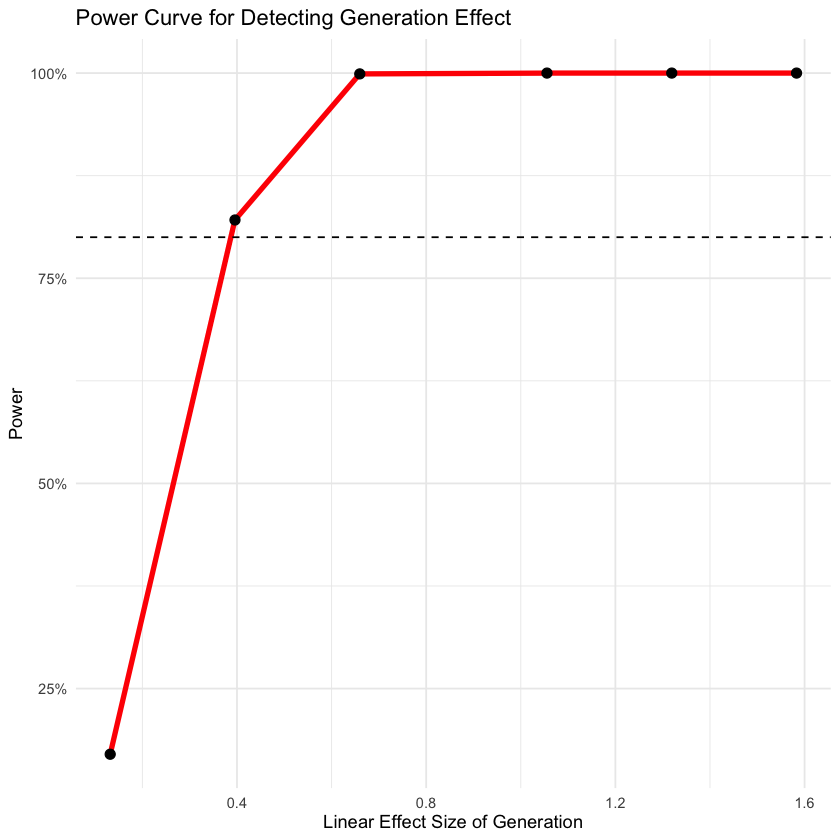

In [ ]:
effects_to_try <- beta_fitted * c(0.1, 0.3, 0.5, 0.8, 1.0, 1.2)

nsim <- 1000

power_results <- purrr::map_dfr(
    effects_to_try, ~ power_function(n_sim = nsim, beta = .x, verbose = TRUE)
)
power_results

ggplot(power_results, aes(x = effect, y = power)) +
    geom_line(color = 'red', linewidth = 2) + 
    geom_point(size = 2.5) +
    geom_hline(yintercept = 0.8, linetype = 'dashed') + 
    theme_classic() + 
    scale_y_continuous(labels = scales::percent) + 
    labs(x = 'Linear Effect Size of Generation', y = 'Power', title = 'Power Curve for Detecting Generation Effect')

# Type I error rate

In [40]:
# Empirical Type I error test: simulate under null (beta = 0) and report CI
null_res <- power_function(n_sim = 2000, beta = 0)
print(null_res)

# compute 95% CI 
n_sig_incl <- null_res$power * null_res$n_sim
incl_ci <- prop.test(n_sig_incl, null_res$n_sim)$conf.int
cat("Type I error:", null_res$power, "\n")
cat("      95% CI:", incl_ci[1], "-", incl_ci[2], "\n")

# compute 95% CI conditional on non-singular fits
n_sig_incl <- null_res$power_given_non_singular * null_res$n_sim
incl_ci <- prop.test(n_sig_incl, null_res$n_sim)$conf.int
cat("Type I error (conditional given non-singular fits):", null_res$power_given_non_singular, "\n")
cat("                                         95% CI:", incl_ci[1], "-", incl_ci[2], "\n")


# conservative estimate: singular fits counted as failures
n_sig_non_singular <- null_res$sig_non_singular * null_res$n_sim
non_singular_ci <- prop.test(n_sig_non_singular, null_res$n_sim)$conf.int
cat("\nType I error (singular fits as failures):", null_res$sig_non_singular, "\n")
cat("                                    95% CI:", non_singular_ci[1], "-", non_singular_ci[2], "\n")

# A tibble: 1 × 9
  effect  power power_given_non_sing…¹ n_excluded singular_rate sig_non_singular
   <dbl>  <dbl>                  <dbl>      <int>         <dbl>            <dbl>
1      0 0.0515                  0.042        248         0.124            0.042
# ℹ abbreviated name: ¹​power_given_non_singular
# ℹ 3 more variables: mean_coef <dbl>, sd_coef <dbl>, n_sim <dbl>
Type I error: 0.0515 
      95% CI: 0.04241731 - 0.06234644 

Type I error (singular fits as failures): 0.042 
                                95% CI: 0.03382696 - 0.0519787 


# Num chains

Running power simulation with parameters:
beta: 0.7915227 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.7915227 | sigma_chain: 4.542728 | sigma_part: 0.8424634 | sigma_res: 4.756761 
Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
Running power simulation with parameters:
beta: 0.7915227 | 

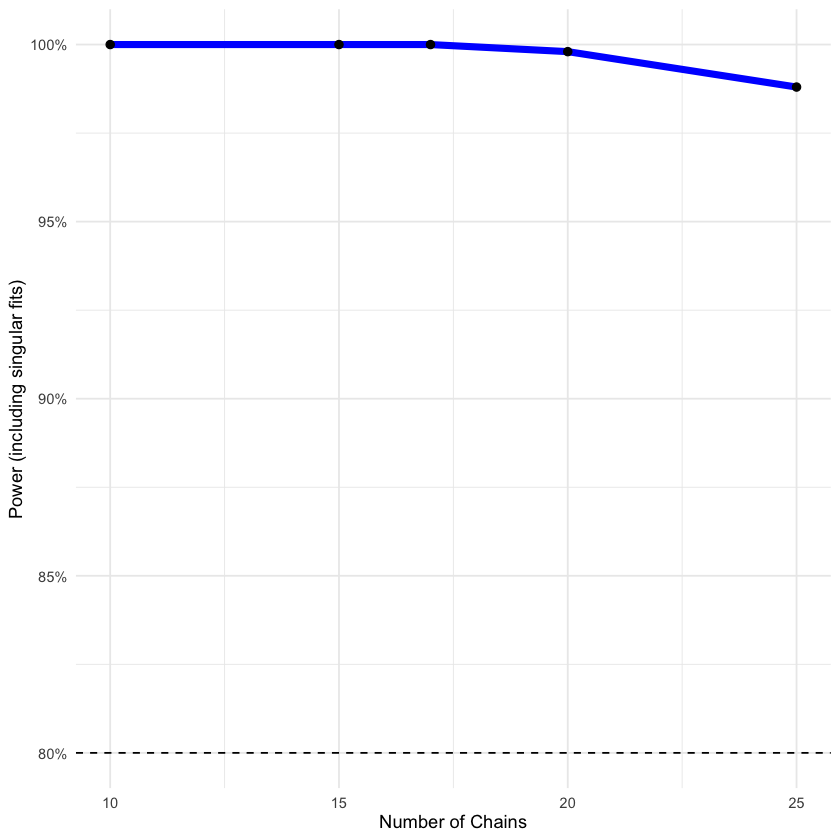

In [ ]:
n_chains_to_try <- c(10, 15, 17, 20, 25)
n_gens_vec <- floor(max_sample_size / n_chains_to_try)
beta <- beta_fitted * 0.6 # use 60% of fitted effect size to be more conservative

power_results_chains <- purrr::map2_dfr(n_chains_to_try, n_gens_vec, function(ch, ge) {
    res <- power_function(chains = ch, gens = ge, beta = beta, verbose = TRUE)
    res %>% dplyr::mutate(n_chains = ch, n_gens = ge)
})

ggplot(power_results_chains, aes(x = n_chains, y = power)) +
    geom_line(color = 'blue', linewidth = 2) + 
    geom_point(size = 2.5) +
    geom_hline(yintercept = 0.8, linetype = 'dashed') + 
    theme_classic() + 
    scale_y_continuous(labels = scales::percent) + 
    labs(x = 'Number of Chains', y = 'Power (including singular fits)')

effect,power,power_given_non_singular,n_excluded,singular_rate,sig_non_singular,mean_coef,sd_coef,n_sim
<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5276818,0.992,0.881,112,0.112,0.881,0.5275981,0.1186909,1000
0.7915227,1.000,0.897,103,0.103,0.897,0.7951527,0.1182528,1000
0.9234431,1.000,0.877,123,0.123,0.877,0.9281335,0.1172251,1000
1.0553635,1.000,0.866,134,0.134,0.866,1.0496127,0.1155088,1000
1.1872840,1.000,0.870,130,0.130,0.870,1.1887798,0.1150717,1000
1.3192044,1.000,0.881,119,0.119,0.881,1.3181829,0.1187005,1000


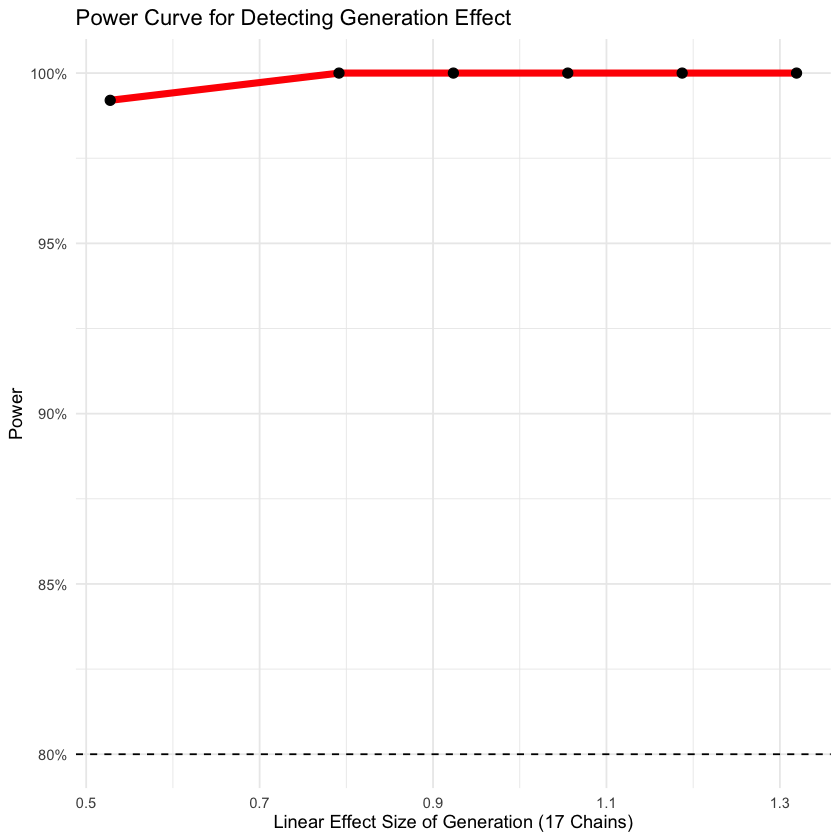

In [ ]:
effects_to_try <- beta_fitted * c(0.4, 0.6, 0.7, 0.8, 0.9, 1.0)

nsim <- 1000
n_chains <- 17
n_gens <- floor(max_sample_size / n_chains)

power_results <- purrr::map_dfr(effects_to_try, ~ power_function(
    n_sim = nsim, chains = n_chains, gens = n_gens, beta = .x)
)
power_results

ggplot(power_results, aes(x = effect, y = power)) +
    geom_line(color = 'red', linewidth = 2) + 
    geom_point(size = 2.5) +
    geom_hline(yintercept = 0.8, linetype = 'dashed') + 
    theme_classic() + 
    scale_y_continuous(labels = scales::percent) + 
    labs(x = 'Linear Effect Size of Generation (17 Chains)', y = 'Power', title = 'Power Curve for Detecting Generation Effect')

# Correction for comparisons

## Get pilot-based parameters for each model

In [27]:
# get number of PCs in pilot data (find columns that start with "pc" and count them)
n_pcs <- sum(startsWith(names(pilot_df), "pc"))

# fit model for each PC and extract variance components and effect of generation
pc_results <- tibble(
    pc = character(),
    var_chain = numeric(),
    var_part = numeric(),
    var_res = numeric(),
    beta_gen = numeric()
)

for (i in 1:n_pcs) {
    pc_name <- paste0("pc", i)
    formula <- as.formula(paste(pc_name, "~ generation_centered + (1 | chain) + (1 | participant)"))
    model <- lmer(formula, data = pilot_df)
    
    var_chain <- attr(VarCorr(model)$chain, "stddev")
    var_part <- attr(VarCorr(model)$`participant`, "stddev")
    var_res <- sigma(model)
    beta_gen <- summary(model)$coefficients["generation_centered", "Estimate"]
    
    pc_results <- bind_rows(
        pc_results,
        tibble(
            pc = pc_name,
            var_chain = var_chain,
            var_part = var_part,
            var_res = var_res,
            beta_gen = beta_gen
        )
    )
}
print(pc_results)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



# A tibble: 5 × 5
  pc      var_chain var_part var_res beta_gen
  <chr>       <dbl>    <dbl>   <dbl>    <dbl>
1 pc1   0.000000587    3.60     4.57   -0.322
2 pc2   4.54           0.842    4.76    1.32 
3 pc3   0              1.05     5.82   -3.48 
4 pc4   1.79           1.66     5.03   -2.80 
5 pc5   0              2.85     4.61   -0.364


## Simulation

In [54]:
# function to simulate the full PC analysis with Holm correction
power_corrected <- function(n_sim = 1000,
                            max_sample_size = 106,
                            chains = 17,
                            obs_per_part = obs_per_participant,
                            beta_scaling = 0.6,
                            correction = "holm",
                            alpha = 0.05,
                            verbose = FALSE) {
    pc_params <- pc_results %>%
        mutate(
            sigma_chain = var_chain,
            sigma_part = var_part,
            sigma_res = var_res,
            beta = beta_gen,
            beta_scaled = beta_gen * beta_scaling # use a smaller effect size for more conservative power estimate
        ) %>%
        select(pc, sigma_chain, sigma_part, sigma_res, beta, beta_scaled)

    pc_names <- pc_params$pc
    n_pcs <- nrow(pc_params)
    n_gens <- floor(max_sample_size / chains)
    participants <- chains * n_gens

    sig_mat <- matrix(FALSE, nrow = n_sim, ncol = n_pcs)
    colnames(sig_mat) <- pc_names
    family_any_reject <- logical(n_sim)

    for (s in seq_len(n_sim)) {
        if (verbose && s %% 100 == 0) {
            cat("Simulation iteration:", s, "/", n_sim, "\n")
            flush.console()
        }

        # base structure shared across all PCs
        base <- expand.grid(
            chain = factor(1:chains),
            generation = factor(1:n_gens)
        ) %>% # expand to observation level
            mutate(
                participant = factor(row_number()),
                n_obs = sample(obs_per_part, participants, replace = TRUE),
                generation_centered = as.numeric(generation) - 1
            ) %>%
            # mutate(chain_effect = rnorm(chains, 0, 1)[as.numeric(chain)]) %>%  # placeholder, overwritten per PC
            slice(rep(1:n(), times = n_obs)) %>%
            select(-n_obs) %>%
            group_by(participant) %>%
            mutate(obs_id = 1:n()) %>%
            ungroup()

        # add one outcome column per PC with corresponding random effects
        for (j in seq_len(n_pcs)) {
            pc_name <- pc_names[j]
            beta_j <- pc_params$beta_scaled[j] # use the scaled effect size for more conservative power estimate
            sigma_chain_j <- pc_params$sigma_chain[j]
            sigma_part_j <- pc_params$sigma_part[j]
            sigma_res_j <- pc_params$sigma_res[j]

            # draw chain effects once per chain, index by chain membership
            chain_effects <- rnorm(chains, 0, sigma_chain_j)
            u_c <- chain_effects[as.numeric(base$chain)]
            
            # participant effects once per participant, index by participant membership
            part_effects <- rnorm(participants, 0, sigma_part_j)
            v_p <- part_effects[as.numeric(base$participant)]

            base[[pc_params$pc[j]]] <- beta_j * base$generation_centered +
                u_c + v_p +
                rnorm(nrow(base), 0, sigma_res_j)
        }

        # fit model for each PC and collect p-values
        pvals <- numeric(n_pcs)
        for (j in seq_len(n_pcs)) {
            pc_name <- pc_names[j]
            model_j <- suppressMessages(suppressWarnings(
                lmer(as.formula(paste(
                    pc_name, "~ generation_centered + (1 | chain) + (1 | participant)")),
                    data = base
            )))
            pvals[j] <- coef(summary(model_j))["generation_centered", "Pr(>|t|)"]
        }

        # Holm correction: order p-values, apply sequentially tightening threshold
        p_adj <- p.adjust(pvals, method = correction)
        sig_mat[s, ] <- p_adj <= alpha
        family_any_reject[s] <- any(sig_mat[s, ])
    }

    tibble(
        pc = pc_names,
        power_holm = colMeans(sig_mat),
        beta = pc_params$beta,
        beta_scaled = pc_params$beta_scaled,
        n_sim = n_sim,
        chains = chains,
        generations = n_gens,
        participants = participants,
        correction = correction,
        family_any_reject = mean(family_any_reject)
    )
}

In [55]:
pc_power_17 <- power_corrected(n_sim = 1000, chains = 17, beta_scaling = 0.6, correction = "holm", verbose = TRUE)
print(pc_power_17)

Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
# A tibble: 5 × 10
  pc    power_holm   beta beta_scaled n_sim chains generations participants
  <chr>      <dbl>  <dbl>       <dbl> <dbl>  <dbl>       <dbl>        <dbl>
1 pc1        0.096 -0.322      -0.193  1000     17           6          102
2 pc2        1      1.32        0.792  1000     17           6          102
3 pc3        1     -3.48       -2.09   1000     17           6          102
4 pc4        1     -2.80       -1.68   1000     17           6          102
5 pc5        0.164 -0.364      -0.218  1000     17           6          102
# ℹ 2 more variables: correction <chr>, family_any_reject <dbl>


In [56]:
pc_power_17_summary <- pc_power_17 %>%
    summarise(
        mean_power = mean(power_holm),
        min_power = min(power_holm),
        max_power = max(power_holm),
        family_any_reject = first(family_any_reject)
    )
print(pc_power_17_summary)

# A tibble: 1 × 4
  mean_power min_power max_power family_any_reject
       <dbl>     <dbl>     <dbl>             <dbl>
1      0.652     0.096         1                 1


In [57]:
pc_power_17 <- power_corrected(n_sim = 1000, chains = 17, beta_scaling = 0.8, correction = "holm", verbose = TRUE)
print(pc_power_17)

pc_power_17_summary <- pc_power_17 %>%
    summarise(
        mean_power = mean(power_holm),
        min_power = min(power_holm),
        max_power = max(power_holm),
        family_any_reject = first(family_any_reject)
    )
print(pc_power_17_summary)

Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
# A tibble: 5 × 10
  pc    power_holm   beta beta_scaled n_sim chains generations participants
  <chr>      <dbl>  <dbl>       <dbl> <dbl>  <dbl>       <dbl>        <dbl>
1 pc1        0.137 -0.322      -0.257  1000     17           6          102
2 pc2        1      1.32        1.06   1000     17           6          102
3 pc3        1     -3.48       -2.78   1000     17           6          102
4 pc4        1     -2.80       -2.24   1000     17           6          102
5 pc5        0.236 -0.364      -0.291  1000     17           6          102
# ℹ 2 more variables: correction <chr>, family_any_reject <dbl>
# A tibble: 1 × 4
  mean_power min_power max

In [58]:
power_corrected <- power_corrected(n_sim = 1000, chains = 21, beta_scaling = 0.8, correction = "holm", verbose = TRUE)
print(power_corrected)

power_corrected_summary <- power_corrected %>%
    summarise(
        mean_power = mean(power_holm),
        min_power = min(power_holm),
        max_power = max(power_holm),
        family_any_reject = first(family_any_reject)
    )
print(power_corrected_summary)

Simulation iteration: 100 / 1000 
Simulation iteration: 200 / 1000 
Simulation iteration: 300 / 1000 
Simulation iteration: 400 / 1000 
Simulation iteration: 500 / 1000 
Simulation iteration: 600 / 1000 
Simulation iteration: 700 / 1000 
Simulation iteration: 800 / 1000 
Simulation iteration: 900 / 1000 
Simulation iteration: 1000 / 1000 
# A tibble: 5 × 10
  pc    power_holm   beta beta_scaled n_sim chains generations participants
  <chr>      <dbl>  <dbl>       <dbl> <dbl>  <dbl>       <dbl>        <dbl>
1 pc1        0.099 -0.322      -0.257  1000     21           5          105
2 pc2        1      1.32        1.06   1000     21           5          105
3 pc3        1     -3.48       -2.78   1000     21           5          105
4 pc4        1     -2.80       -2.24   1000     21           5          105
5 pc5        0.168 -0.364      -0.291  1000     21           5          105
# ℹ 2 more variables: correction <chr>, family_any_reject <dbl>
# A tibble: 1 × 4
  mean_power min_power max